In [23]:
'''Task 1 - Data Scraping
● Create a Scrapy spider that follows catalog pagination and visits each individual book page.
● Extract all required fields and export the raw records to CSV or JSON format.
● Report the total number of scraped records, missing values, and duplicate UPC values.'''

import scrapy


class BooksSpider(scrapy.Spider):
    name = "books"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]

    def parse(self, response):

        # Getting links to individual book pages
        book_links = response.css("article.product_pod h3 a::attr(href)").getall()

        for link in book_links:
            yield response.follow(link, callback=self.parse_book)
            
        
        # Check the current page so the spider only scrapes the first 5 pages
        current_page = int(response.url.split("page-")[-1].split(".")[0])


        if current_page < 5:
            next_page = response.css("li.next a::attr(href)").get()

            if next_page:
                yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):

        book_info = {}

        # Reading book details from the product info table
        rows = response.css("table.table.table-striped tr")

        for row in rows:
            key = row.css("th::text").get()
            value = row.css("td::text").get()
            book_info[key] = value

        # Getting the book description
        description = response.css(
            "#product_description + p::text").get(default="")

        # Extraction of category
        category = response.css("ul.breadcrumb li:nth-child(3) a::text").get()

        # Get star rating

        rating = response.css("p.star-rating::attr(class)").get().split()[-1]

        # Getting stock availability
        
        availability = "".join(response.css("p.availability::text").getall()).strip()

        yield {
            "title": response.css("div.product_main h1::text").get(),
            "category": category,
            "price": response.css("p.price_color::text").get(),
            "rating": rating,
            "availability": availability,
            "description": description,
            "upc": book_info.get("UPC"),
            "num_reviews": book_info.get("Number of reviews"),
            "product_url": response.url,
        }

In [24]:
'''Task 2 - Data Preprocessing
● Clean up extra spaces and inconsistent text; remove duplicate books by UPC; handle missing
descriptions.
● Convert price to a numeric value, map ratings One-Five to integers, and extract the available stock
count.
● Create at least three useful features, such as description_word_count, price_band, affordability_score,
value_score, or recommended.'''

import pandas as pd
import numpy as np

# Load the raw dataset
df = pd.read_csv("D:\\BookScrapingAssignment\\bookscraper\\books_raw.csv")

# Report Task 1 results
print(f"Total records scraped: {len(df)}")

print("\nMissing values in each column:")
print(df.isnull().sum())

print(f"\nDuplicate UPC values: {df['upc'].duplicated().sum()}")

# Clean text columns
text_columns = ["title", "category", "availability", "description"]

for col in text_columns:
    df[col] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Remove duplicate books using UPC

df = df.drop_duplicates(subset="upc")

# Handle missing descriptions
df["description"] = df["description"].replace("", "No Description Available")

# Convert price to numeric
df["price"] = (
    df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

# Convert ratings to integers

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

# Extract stock count

df["stock_count"] = (
    df["availability"]
    .str.extract(r"(\d+)")
    .fillna(0)
    .astype(int)
)

# Creating new features

# Price band
df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, np.inf],
    labels=["Cheap", "Moderate", "Expensive"]
)

# Affordability 
df["affordability"] = (
    df["rating"] / df["price"]
).round(3)

# Value 
df["value"] = (
    (df["rating"] * df["stock_count"]) / df["price"]
).round(3)

# Recommendation
df["recommended"] = ((df["rating"] > 3) &(df["price"] < 45))

# Description word count
df["description_word_count"] = (
    df["description"]
    .str.split()
    .str.len()
)


# Saving clean dataset
df.to_csv("books_clean.csv", index=False)
print("Preprocessing completed.")
print("Clean dataset saved as books_clean.csv")
print(f"Total Books: {len(df)}")
print("\nFirst 5 Records:")
print(df.head())

Total records scraped: 100

Missing values in each column:
title           0
category        0
price           0
rating          0
availability    0
description     0
upc             0
num_reviews     0
product_url     0
dtype: int64

Duplicate UPC values: 0
Preprocessing completed.
Clean dataset saved as books_clean.csv
Total Books: 100

First 5 Records:
                                               title         category  price  \
0                            It's Only the Himalayas           Travel  45.17   
1                       Libertarianism for Beginners         Politics  51.33   
2  Mesaerion: The Best Science Fiction Stories 18...  Science Fiction  37.59   
3                                               Olio           Poetry  23.88   
4  Our Band Could Be Your Life: Scenes from the A...            Music  57.25   

   rating                                       availability  \
0       2  In stock (19 available) In stock In stock In s...   
1       2  In stock (19 available

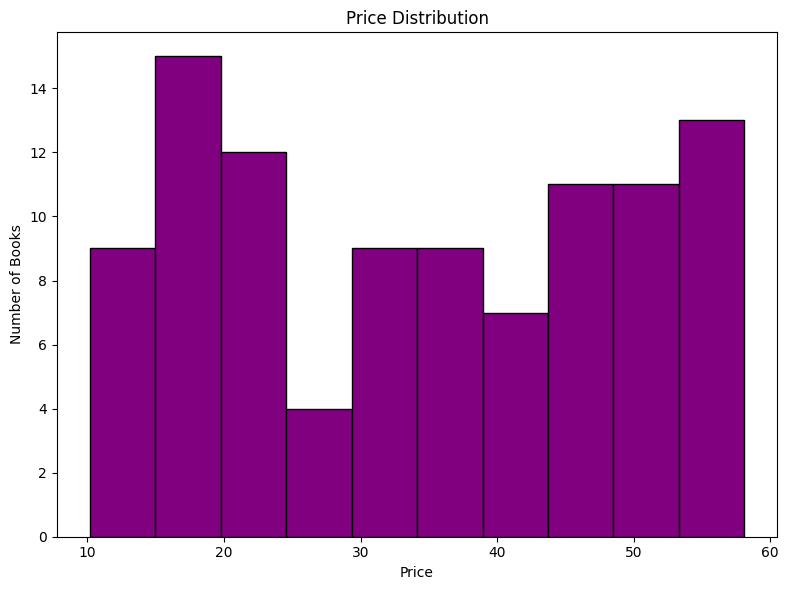

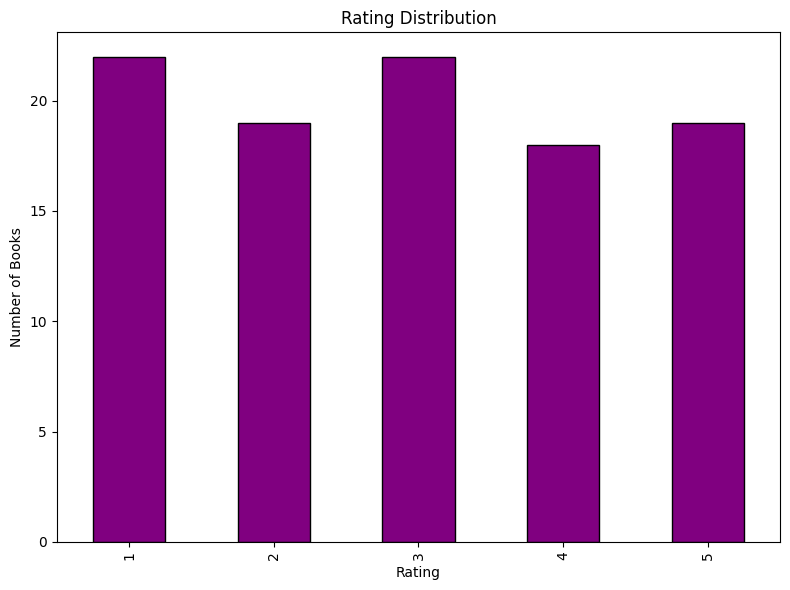

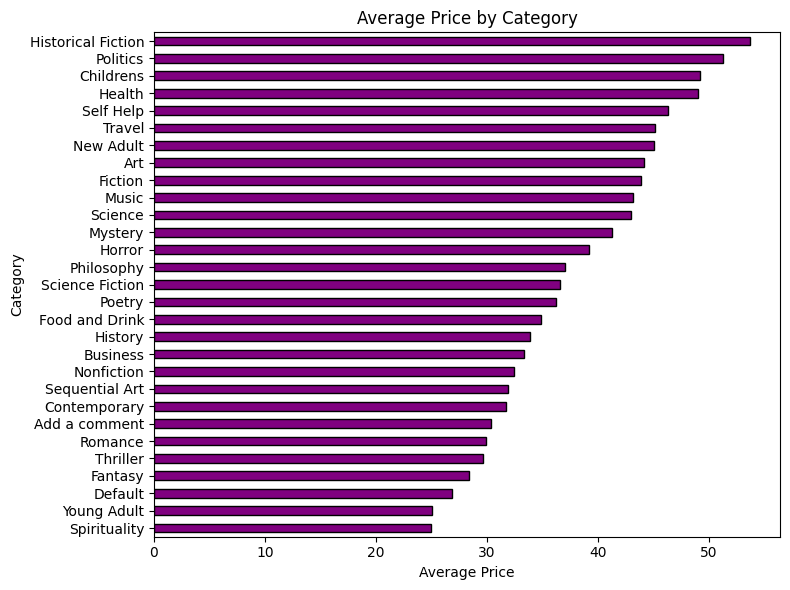

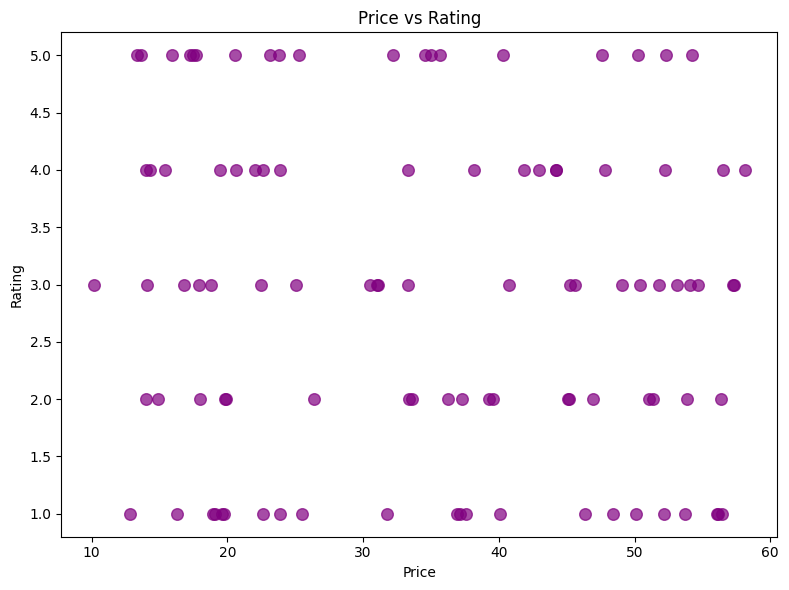

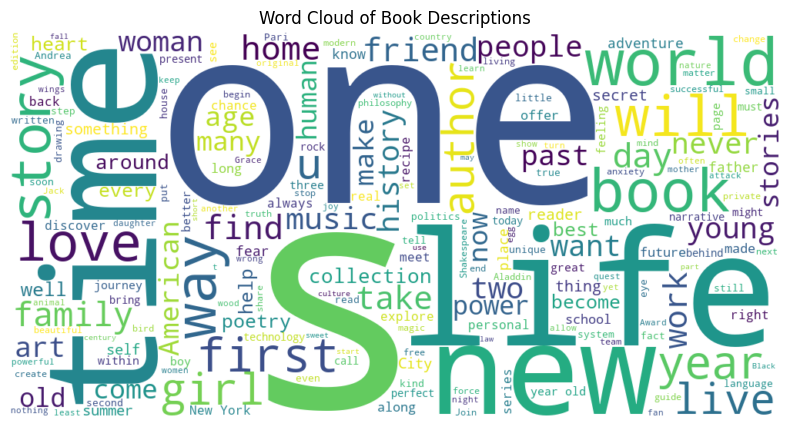


------------------SUMMARY STATISTICS------------------

            price      rating  num_reviews  stock_count  affordability  \
count  100.000000  100.000000        100.0   100.000000     100.000000   
mean    34.560700    2.930000          0.0    17.180000       0.108700   
std     14.638531    1.423149          0.0     1.479694       0.084838   
min     10.160000    1.000000          0.0    16.000000       0.018000   
25%     19.897500    2.000000          0.0    16.000000       0.051000   
50%     34.775000    3.000000          0.0    16.000000       0.081000   
75%     47.967500    4.000000          0.0    19.000000       0.143500   
max     58.110000    5.000000          0.0    22.000000       0.375000   

            value  description_word_count  
count  100.000000              100.000000  
mean     1.857940              224.710000  
std      1.428529              107.798474  
min      0.284000               36.000000  
25%      0.838750              163.750000  
50%      1.4

In [25]:
'''Task 3 - Visualization and Analysis
● Generate at least four meaningful plots, including price distribution, rating distribution, average price
by category, and one relationship plot such as price vs rating or category vs stock.
● Generate a word cloud from the combined book descriptions. The selected website does not provide
written customer-review text, so descriptions must be used as the textual source.
● Use summary statistics and plots to identify category patterns, highly rated books, stock patterns, and
any unusual or missing values.'''


import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load cleaned dataset
df = pd.read_csv("books_clean.csv")


# Price Distribution

plt.figure(figsize=(8,6))
plt.hist(df["price"], bins=10,color="purple",edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()


#  Rating Distribution

plt.figure(figsize=(8,6))
df["rating"].value_counts().sort_index().plot(kind="bar",color="purple",edgecolor="black")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("rating_distribute.png")
plt.show()


#  Average Price by Category

avg_price = df.groupby("category")["price"].mean().sort_values()

plt.figure(figsize=(8,6))
avg_price.plot(kind="barh",color="purple",edgecolor="black")
plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("average_price_by_category.png")
plt.show()

# Price vs Rating graph

plt.figure(figsize=(8,6))
plt.scatter(df["price"], df["rating"],color="purple",s=70,alpha=0.7)
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("price_vs_rating.png")
plt.show()


#  Word Cloud

text = " ".join(df["description"].fillna(""))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")
plt.tight_layout()
plt.savefig("wordcloud.png")
plt.show()

# Summary Statistics

print("\n------------------SUMMARY STATISTICS------------------\n")
print(df.describe())

print("\n------------------BOOK COUNT BY CATEGORY------------------\n")
print(df["category"].value_counts())

print("\n------------------PRICE BY CATEGORY (Average)------------------\n")
print(df.groupby("category")["price"].mean().sort_values(ascending=False))

print("\n------------------RATING BY CATEGORY (Average)------------------\n")
print(df.groupby("category")["rating"].mean().sort_values(ascending=False))

print("\n------------------MOST EXPENSIVE BOOKS (Top 10)------------------\n")
print(df[["title", "price"]].sort_values(by="price", ascending=False).head(10))

print("\n------------------TOP RATED BOOKS------------------\n")
print(df[df["rating"] == 5][["title", "category", "price"]])

print("\n------------------STOCK SUMMARY------------------\n")
print(df["stock_count"].describe())

print("\n------------------MISSING VALUES------------------\n")
print(df.isnull().sum())


